Insurance Claims Frequency & Severity Model

In [ ]:
# Data Loading

# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning datasets
from sklearn.datasets import fetch_openml

# Display settings
pd.set_option("display.max_columns", None)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
# Load the French Motor Third-Party Liability Frequency Dataset

# Fetch dataset from OpenML
motor = fetch_openml(name="freMTPL2freq", version=1, as_frame=True)

# Extract dataframe
df = motor.frame.copy()

print("Dataset loaded successfully.")
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of variables: {df.shape[1]}")

print(df.columns)
df.describe().T

Dataset loaded successfully.
Number of observations: 678,013
Number of variables: 12
Index(['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge',
       'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region'],
      dtype='object')


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


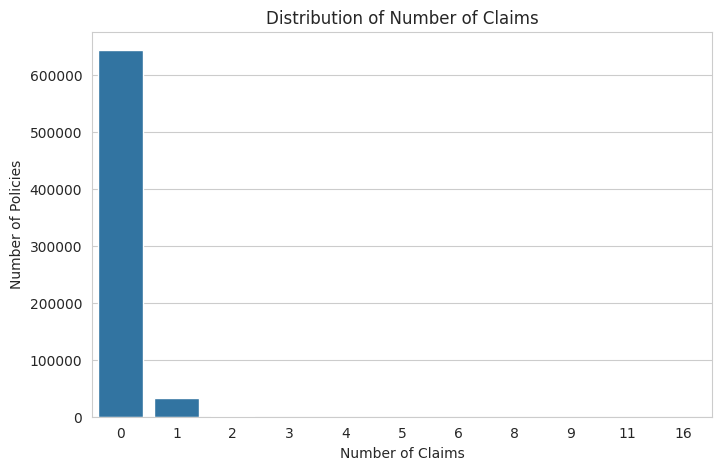

In [ ]:
# Visualise number of claims per policy
# Most policies have zero claims, confirming strong class imbalance.

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="ClaimNb")

plt.title("Distribution of Number of Claims")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")
plt.show()

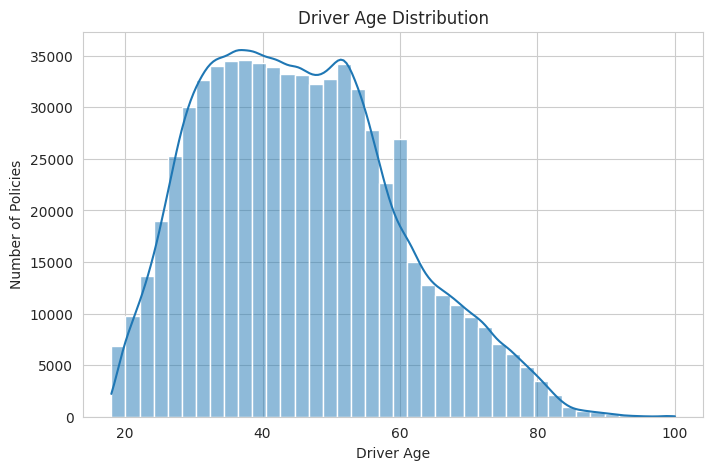

In [ ]:
# Visualise number of policies by driver age
plt.figure(figsize=(8,5))

sns.histplot(df["DrivAge"], bins=40, kde=True)

plt.title("Driver Age Distribution")
plt.xlabel("Driver Age")
plt.ylabel("Number of Policies")

plt.show()

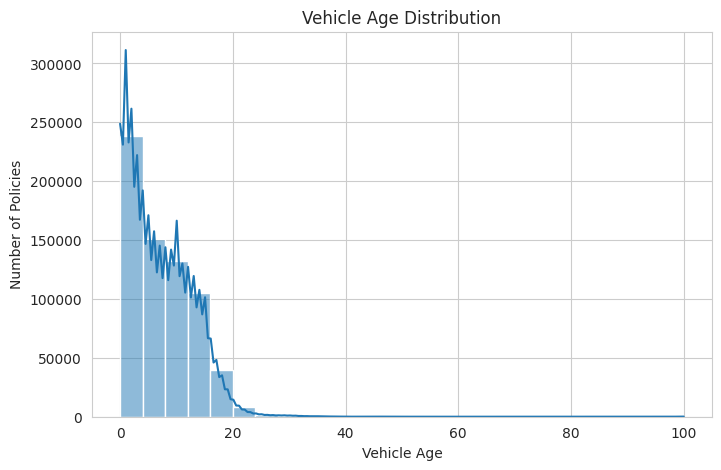

In [ ]:
# Visualise number of policies by vehicle age
plt.figure(figsize=(8,5))

sns.histplot(df["VehAge"], bins=25, kde=True)

plt.title("Vehicle Age Distribution")
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Policies")

plt.show()

/tmp/ipykernel_4298/2070859564.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  frequency_by_age = (df.groupby("DriverAgeGroup") .agg(MeanClaims=("ClaimNb","mean")).reset_index())


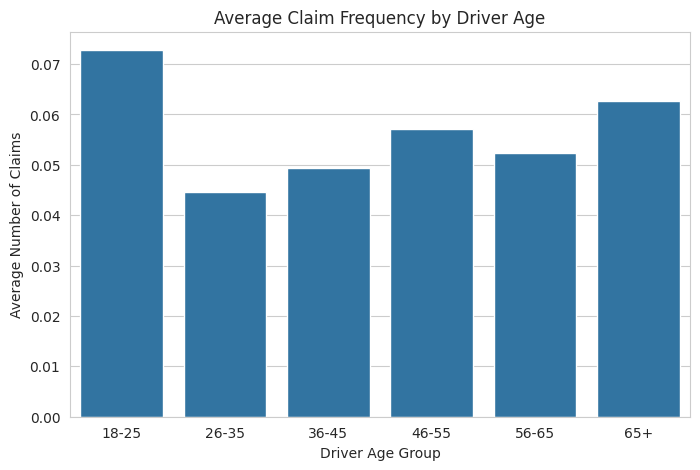

In [ ]:
# Create driver age groups and get frequency for each
df["DriverAgeGroup"] = pd.cut(df["DrivAge"], bins=[18,25,35,45,55,65,100], labels=["18-25", "26-35", "36-45", "46-55", "56-65", "65+"])
frequency_by_age = (df.groupby("DriverAgeGroup") .agg(MeanClaims=("ClaimNb","mean")).reset_index())

# Visualise claim frequency by driver age
plt.figure(figsize=(8,5))

sns.barplot( data=frequency_by_age,  x="DriverAgeGroup", y="MeanClaims")

plt.title("Average Claim Frequency by Driver Age")
plt.xlabel("Driver Age Group")
plt.ylabel("Average Number of Claims")

plt.show()

Feature Engineering

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Calculate claim frequency

# Frequency = Number of claims / Exposure
df["ClaimFreq"] = df["ClaimNb"] / df["Exposure"]

# Remove infinite values
df["ClaimFreq"] = (df["ClaimFreq"].replace([np.inf, -np.inf], np.nan))

# Drop missing frequencies
df = df.dropna(subset=["ClaimFreq"])

df["ClaimFreq"].describe()

,ClaimFreq
count,678013.000000
mean,0.263964
std,4.593915
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,732.000000


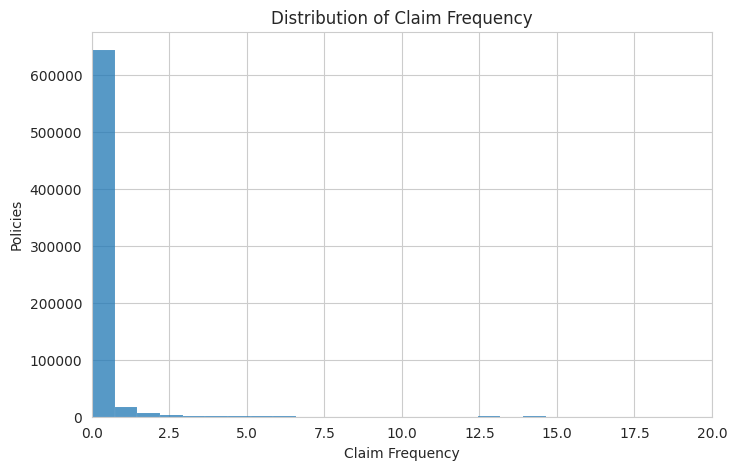

In [ ]:
# Visualise claim frequency
plt.figure(figsize=(8,5))

sns.histplot(df["ClaimFreq"], bins=1000)

plt.title("Distribution of Claim Frequency")
plt.xlabel("Claim Frequency")
plt.ylabel("Policies")

ax = plt.gca()
ax.set_xlim([0,20])

plt.show()

In [ ]:
# Get catagorical variables and one hot encode
categorical_columns = df.select_dtypes(include="object").columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(678013, 14)


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,Density,Region,DriverAgeGroup,ClaimFreq,VehGas_'Regular'
0,1.0,1,0.10,D,5,0,55,50,B12,1217,R82,46-55,10.000000,True
1,3.0,1,0.77,D,5,0,55,50,B12,1217,R82,46-55,1.298701,True
2,5.0,1,0.75,B,6,2,52,50,B12,54,R22,46-55,1.333333,False
3,10.0,1,0.09,B,7,0,46,50,B12,76,R72,46-55,11.111111,False
4,11.0,1,0.84,B,7,0,46,50,B12,76,R72,46-55,1.190476,False


In [ ]:
# Remove variables that should not be used as predictors
X = df_encoded.drop(columns=["ClaimNb", "ClaimFreq"])

# Target variable
y = df_encoded["ClaimFreq"]

In [ ]:
# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

Training observations: 542410
Testing observations : 135603


In [ ]:
# Save exposure seperately, to be used as offset
train_exposure = X_train["Exposure"]
test_exposure = X_test["Exposure"]

In [ ]:
print("Training feature matrix :", X_train.shape)
print("Testing feature matrix  :", X_test.shape)

print("Training target         :", y_train.shape)
print("Testing target          :", y_test.shape)

Training feature matrix : (542410, 12)
Testing feature matrix  : (135603, 12)
Training target         : (542410,)
Testing target          : (135603,)


Part 3 - Frequency Modelling

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
# Reconstruct training data
train_df = X_train.copy()
train_df["ClaimFreq"] = y_train
train_df["Exposure"] = train_exposure

# Aim is to model claim frequency = expected number of claims per unit exposure
# Using a poisson GLM

# Offset model by exposure
poisson_model = smf.glm(
    formula="""ClaimFreq ~ DrivAge + VehAge + BonusMalus + Density""",
    data=train_df,
    family=sm.families.Poisson(),
    offset=np.log(train_df["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              ClaimFreq   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542405
Model Family:                 Poisson   Df Model:                            4
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -9.3039e+05
Date:                Thu, 09 Jul 2026   Deviance:                   1.7870e+06
Time:                        12:12:14   Pearson chi2:                 4.13e+09
No. Iterations:                    10   Pseudo R-squ. (CS):             0.1162
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0817      0.017    -64.121      0.0

In [ ]:
# Calculate model coefficients
coefficients = pd.DataFrame({
    "Variable": poisson_model.params.index,
    "Coefficient": poisson_model.params.values,
    "Exp(Coeff)": np.exp(poisson_model.params.values)
})

coefficients

,Variable,Coefficient,Exp(Coeff)
0,Intercept,-1.081691,0.339022
1,DrivAge,-0.003538,0.996468
2,VehAge,-0.123671,0.883670
3,BonusMalus,0.020840,1.021059
4,Density,0.000013,1.000013


In [ ]:
# Predic ton test set
test_df = X_test.copy()
test_df["Exposure"] = test_exposure

# Predict expected frequency
test_pred = poisson_model.predict(test_df, offset=np.log(test_df["Exposure"]))
test_df["PredFreq"] = test_pred

In [ ]:
# Compare actual vs predicted
results = pd.DataFrame({"Actual": y_test, "Predicted": test_pred})
results.head()

# Aggregate to remove noise
results["DrivAge"] = test_df["DrivAge"]
age_perf = results.groupby(pd.cut(results["DrivAge"], bins=6)).mean()
age_perf

/tmp/ipykernel_4298/2035650051.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_perf = results.groupby(pd.cut(results["DrivAge"], bins=6)).mean()


,Actual,Predicted,DrivAge
DrivAge,,,
"(17.919, 31.5]",0.319310,0.323518,26.772158
"(31.5, 45.0]",0.255127,0.243592,38.477556
"(45.0, 58.5]",0.296509,0.241065,51.634895
"(58.5, 72.0]",0.271753,0.249499,64.558617
"(72.0, 85.5]",0.238557,0.260784,76.983516
"(85.5, 99.0]",0.254124,0.240678,88.930233


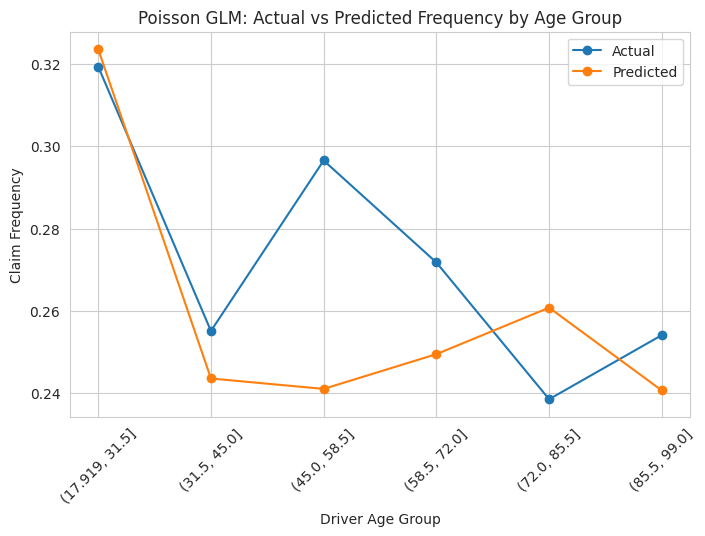

In [ ]:
# Visualise predicted vs actual frequency
plt.figure(figsize=(8,5))

plt.plot(age_perf.index.astype(str), age_perf["Actual"], marker="o", label="Actual")
plt.plot(age_perf.index.astype(str), age_perf["Predicted"], marker="o", label="Predicted")

plt.xticks(rotation=45)
plt.title("Poisson GLM: Actual vs Predicted Frequency by Age Group")
plt.xlabel("Driver Age Group")
plt.ylabel("Claim Frequency")

plt.legend()
plt.show()

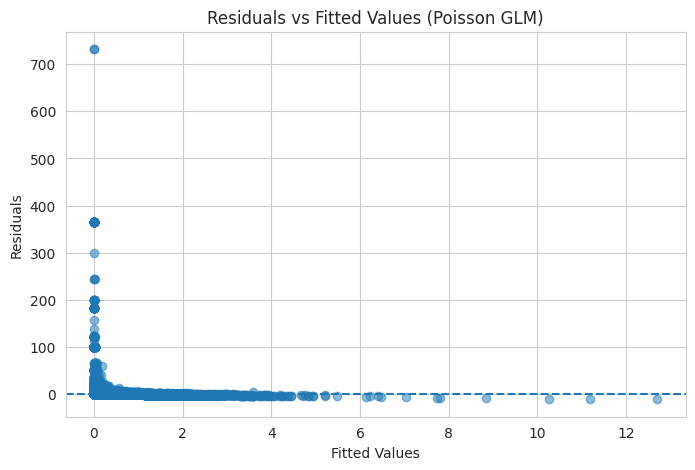

In [ ]:
# Plot residuals
residuals = poisson_model.resid_response
fitted = poisson_model.fittedvalues

plt.figure(figsize=(8,5))
plt.scatter(fitted, residuals, alpha=0.5)

plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted Values (Poisson GLM)")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.show()

Severity Model

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
# Now model severity, how severe each claim is on average

# Load severity dataset
sev = fetch_openml(name="freMTPL2sev", version=1,as_frame=True)
sev_df = sev.frame.copy()
print(sev_df.columns)

freq = fetch_openml(name="freMTPL2freq", version=1, as_frame=True)
freq_df = freq.frame.copy()

Index(['IDpol', 'ClaimAmount'], dtype='object')


In [ ]:
# Aggregate severity per policy
sev_agg = (sev_df.groupby("IDpol", as_index=False).agg(TotalClaimAmount=("ClaimAmount", "sum")))

# Merge frequency and severity
df = freq_df.merge(sev_agg, on="IDpol", how="left")
# Replace missing claims with 0
df["TotalClaimAmount"] = df["TotalClaimAmount"].fillna(0)

sev_df_model = df[df["ClaimNb"] > 0].copy()
print("Rows for severity model:", len(sev_df_model))

# Severity = Number of Claims / Total Claim Cost​
sev_df_model["Severity"] = sev_df_model["TotalClaimAmount"] / sev_df_model["ClaimNb"]
sev_df_model = sev_df_model[sev_df_model["Severity"] > 0]


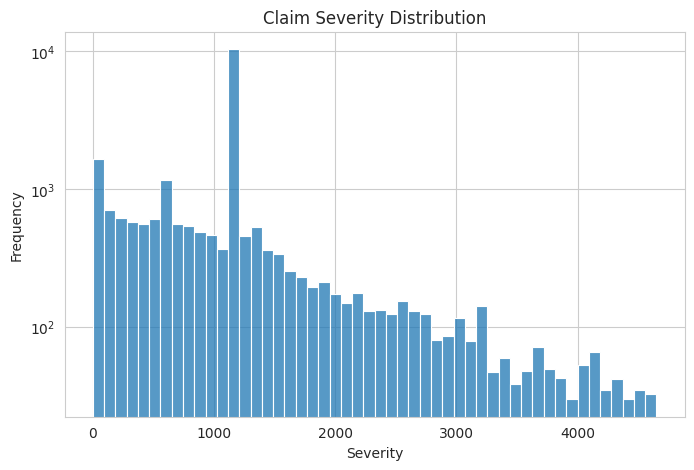

In [ ]:
# Visualise claim severity distribution
plt.figure(figsize=(8,5))

cap = sev_df_model["Severity"].quantile(0.95)
temp = sev_df_model[sev_df_model["Severity"] <= cap]
sns.histplot(temp["Severity"], bins=50)

plt.yscale("log")

plt.title("Claim Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Define model features
sev_df_model = sev_df_model[["Severity", "DrivAge", "VehAge", "BonusMalus", "Density"]].copy()

# Test and train split
sev_train, sev_test = train_test_split(sev_df_model, test_size=0.2, random_state=42)

In [ ]:
# Fit gamma GLM
gamma_model = smf.glm(
    formula="""Severity ~ DrivAge + VehAge + BonusMalus + Density""",
    data=sev_train,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(gamma_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


                 Generalized Linear Model Regression Results                  
Dep. Variable:               Severity   No. Observations:                19955
Model:                            GLM   Df Residuals:                    19950
Model Family:                   Gamma   Df Model:                            4
Link Function:                    log   Scale:                          87.626
Method:                          IRLS   Log-Likelihood:            -2.2737e+05
Date:                Thu, 09 Jul 2026   Deviance:                       33549.
Time:                        12:39:35   Pearson chi2:                 1.75e+06
No. Iterations:                    21   Pseudo R-squ. (CS):          0.0008419
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.3821      0.419     17.601      0.0

In [ ]:
# Predict on test set
sev_test = sev_test.copy()
sev_test["PredSeverity"] = gamma_model.predict(sev_test)
sev_test[["Severity", "PredSeverity"]].head()

,Severity,PredSeverity
545213,3204.00,1996.264701
444592,395.88,1758.816830
410728,1204.00,2250.441487
168106,1128.00,2375.629222
141212,2528.12,2547.083357


In [ ]:
# Group for evaluation
sev_test["AgeGroup"] = pd.cut(sev_test["DrivAge"], bins=6)
grouped = sev_test.groupby("AgeGroup")[["Severity", "PredSeverity"]].mean()
grouped

/tmp/ipykernel_4298/1564872226.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = sev_test.groupby("AgeGroup")[["Severity", "PredSeverity"]].mean()


,Severity,PredSeverity
AgeGroup,,
"(17.923, 30.833]",2513.942617,3040.838902
"(30.833, 43.667]",1669.295541,2338.309461
"(43.667, 56.5]",1864.598239,2025.120342
"(56.5, 69.333]",1535.496332,1872.156553
"(69.333, 82.167]",2914.807883,1697.096427
"(82.167, 95.0]",6854.869444,1797.005120


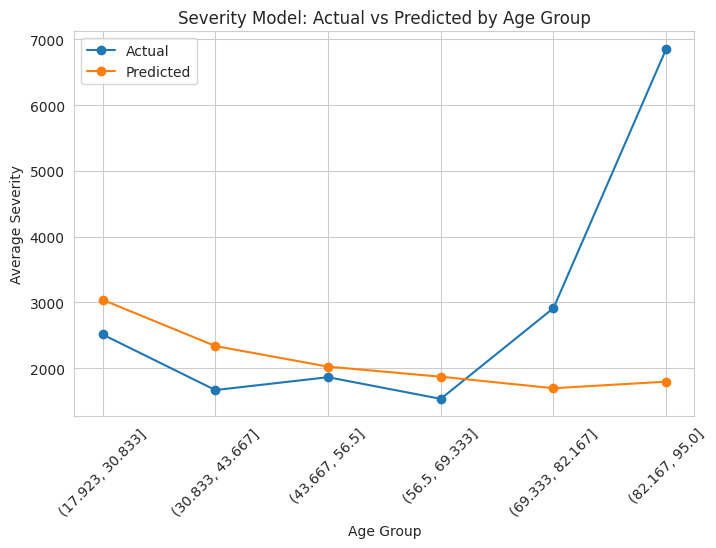

In [ ]:
# Visualise predicted vs actual severity
plt.figure(figsize=(8,5))

plt.plot(grouped.index.astype(str), grouped["Severity"], marker="o", label="Actual")
plt.plot(grouped.index.astype(str), grouped["PredSeverity"], marker="o", label="Predicted")

plt.xticks(rotation=45)
plt.title("Severity Model: Actual vs Predicted by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Severity")

plt.legend()
plt.show()

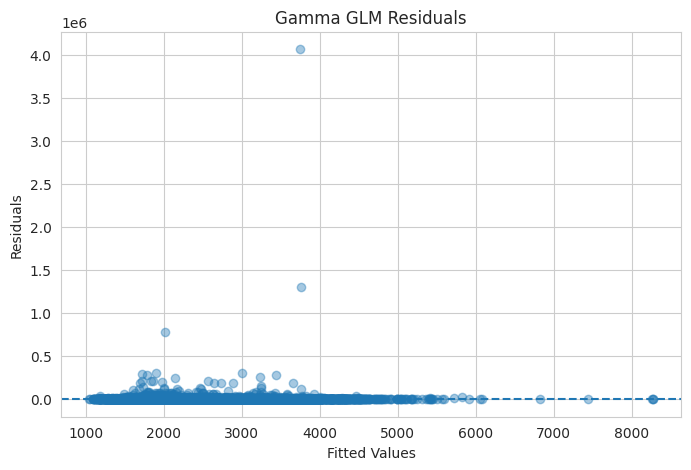

In [ ]:
# Plot residuals
residuals = gamma_model.resid_response
fitted = gamma_model.fittedvalues

plt.figure(figsize=(8,5))

plt.scatter(fitted, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")

plt.title("Gamma GLM Residuals")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.show()

Pure Premium Model

In [ ]:
# Predict Frequency for all Policies

freq_pred_df = X.copy()

# Add exposure back
freq_pred_df["Exposure"] = df["Exposure"]

# Predict claim frequency
df["PredictedFrequency"] = poisson_model.predict(freq_pred_df,offset=np.log(freq_pred_df["Exposure"]))

In [ ]:
# Predict severity for claim policies
severity_predictors = df[["DrivAge", "VehAge", "BonusMalus", "Density"]].copy()
df["PredictedSeverity"] = gamma_model.predict(severity_predictors)

In [ ]:
# Pure Premium = Predicted Frequency * Predicted Severity
df["PurePremium"] = ( df["PredictedFrequency"] * df["PredictedSeverity"])
df[["PredictedFrequency","PredictedSeverity","PurePremium"]].head()

,PredictedFrequency,PredictedSeverity,PurePremium
0,0.080348,1710.345267,137.422012
1,0.618676,1710.345267,1058.149494
2,0.468605,1807.688357,847.092488
3,0.073578,1834.557171,134.983094
4,0.686728,1834.557171,1259.842208


Results, Visualisations & Business Interpretation

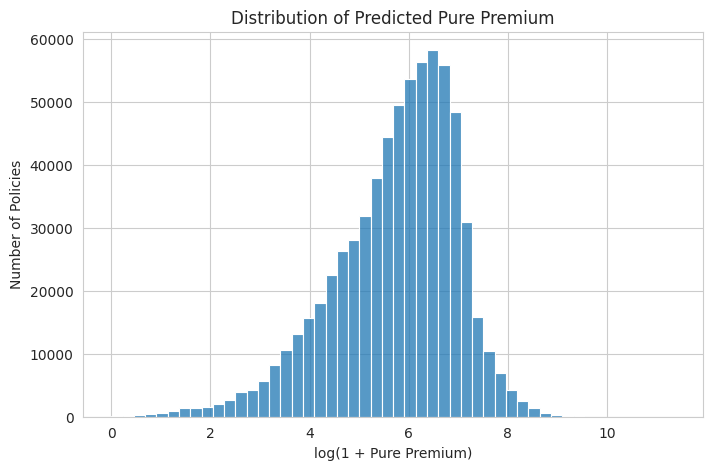

In [ ]:
# Visualise distribution of pure premiums
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["PurePremium"]), bins=50)

plt.title("Distribution of Predicted Pure Premium")
plt.xlabel("log(1 + Pure Premium)")
plt.ylabel("Number of Policies")

plt.show()

/tmp/ipykernel_4298/3827501172.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  premium_by_age = (  df.groupby("AgeGroup")["PurePremium"].mean().reset_index())


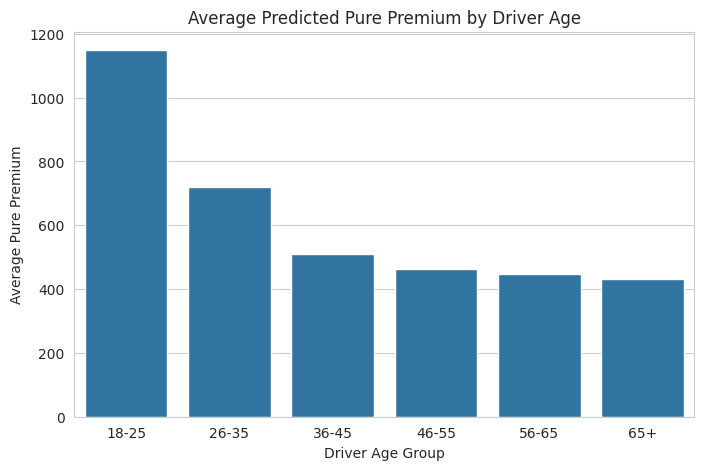

In [ ]:
# Visualis premium by driver age
df["AgeGroup"] = pd.cut(df["DrivAge"], bins=[18,25,35,45,55,65,100], labels=["18-25","26-35","36-45","46-55","56-65","65+"])
premium_by_age = (  df.groupby("AgeGroup")["PurePremium"].mean().reset_index())

plt.figure(figsize=(8,5))
sns.barplot(data=premium_by_age, x="AgeGroup", y="PurePremium")

plt.title("Average Predicted Pure Premium by Driver Age")
plt.xlabel("Driver Age Group")
plt.ylabel("Average Pure Premium")

plt.show()

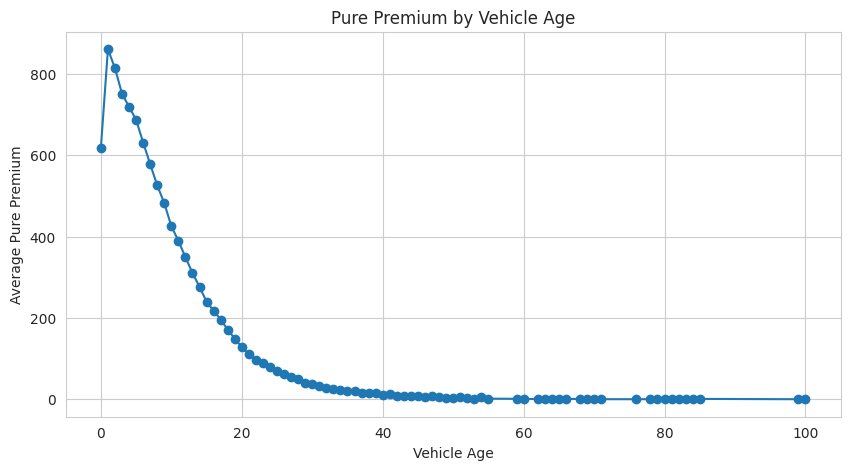

In [ ]:
# Visualise premium by vehicle age
vehicle_premium = (df.groupby("VehAge")["PurePremium"].mean().reset_index())
plt.figure(figsize=(10,5))

plt.plot(vehicle_premium["VehAge"], vehicle_premium["PurePremium"], marker="o")

plt.title("Pure Premium by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Average Pure Premium")

plt.show()

In [ ]:
# Highest risk policies

top_risk = ( df[[
        "IDpol",
        "PredictedFrequency",
        "PredictedSeverity",
        "PurePremium"
    ]]
    .sort_values("PurePremium", ascending=False)
    .head(10)
)

top_risk

,IDpol,PredictedFrequency,PredictedSeverity,PurePremium
18526,41513.0,12.706493,6824.060859,86709.879032
110016,1041514.0,11.188695,6855.252103,76701.326642
178152,1177433.0,10.261445,6199.241473,63613.175271
70401,148841.0,8.849492,6487.354449,57409.791041
86308,177430.0,7.728878,6700.476401,51787.163197
61263,131877.0,7.799658,6029.972231,47031.722631
86309,177431.0,6.467020,6700.476401,43332.116144
157643,1131878.0,6.867985,6057.533875,41603.051006
632672,5093571.0,7.033247,5015.133360,35272.669446
84647,174422.0,6.410771,5453.436009,34960.731644


In [ ]:
severity_coef = pd.DataFrame({
    "Variable": gamma_model.params.index,
    "Coefficient": gamma_model.params.values,
    "Cost Multiplier": np.exp(gamma_model.params.values)
})

severity_coef = severity_coef.round(3)

severity_coef

,Variable,Coefficient,Cost Multiplier
0,Intercept,7.382,1606.944
1,DrivAge,-0.006,0.994
2,VehAge,0.011,1.011
3,BonusMalus,0.008,1.008
4,Density,-0.000,1.000
